# Cognitive Digital Beamforming for Jammer-Resilient Systems

## Complete framework demonstration with the Phase 11 K=20 agent

This notebook demonstrates the implemented narrow-band cognitive beamforming chain with one reproducible example:

1. a 6 × 6 uniform rectangular array (URA) at 10 GHz;
2. a fixed, known signal of interest (SOI) and three moving jammers generated by the framework;
3. multi-source snapshot generation and MUSIC direction-of-arrival (DOA) estimation;
4. lookup-validated multi-target tracking with an IMM tracker and Hungarian association;
5. construction of the 24-dimensional Phase 11 observation from Tracker information;
6. deterministic inference with `phase11_agent_direction_width_K20_mixed_002`;
7. conversion of the direction-plus-width action into predictive nulling weights;
8. comparison with steering, conventional nulling, matched-cadence MVDR, and instantaneous Oracle MVDR;
9. SINR, SOI-gain loss, jammer leakage, null-depth, trajectory, tracking, and beampattern plots;
10. a native `BeamformingEnvPhase11` rollout to verify model/environment compatibility.
11. a verified migration guide for the retained checkpoints and environment families from the other phases.

All angles supplied to beamforming functions are in degrees. Scenario DOAs are stored internally in radians and are converted explicitly. Powers are linear unless a quantity is labelled in dB.

In [1]:
# ============================================================
# 1. Runtime setup, reproducibility, and project imports
# ============================================================

import os
import sys
import random
from importlib.util import find_spec
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from stable_baselines3 import SAC


def is_tfm_project_root(candidate):
    """Return True when *candidate* contains the local src-layout package."""

    return (Path(candidate) / "src" / "tfm").is_dir()


def find_project_root(start_path=None):
    """Locate the portable project even when the kernel starts elsewhere."""

    start = Path.cwd() if start_path is None else Path(start_path)
    start = start.resolve()

    # 1. Optional explicit override. This is useful for unusual IDE setups.
    configured_root = os.environ.get("TFM_PROJECT_ROOT")
    if configured_root:
        candidate = Path(configured_root).expanduser().resolve()
        if is_tfm_project_root(candidate):
            return candidate

    # 2. Normal case: the kernel starts in the project or a subdirectory.
    for candidate in (start, *start.parents):
        if is_tfm_project_root(candidate):
            return candidate

    # 3. If `pip install -r requirements.txt` installed `-e .`, recover the
    #    source tree from the installed `tfm` package instead of the CWD.
    tfm_spec = find_spec("tfm")
    if tfm_spec is not None and tfm_spec.submodule_search_locations:
        package_dir = Path(
            next(iter(tfm_spec.submodule_search_locations))
        ).resolve()
        for candidate in (package_dir, *package_dir.parents):
            if is_tfm_project_root(candidate):
                return candidate

    # 4. Common VS Code case: the kernel starts in the parent directory.
    for folder_name in ("TFM_demo", "TFM"):
        candidate = start / folder_name
        if is_tfm_project_root(candidate):
            return candidate.resolve()

    raise FileNotFoundError(
        "Could not locate the TFM project root.\n"
        f"Kernel working directory: {start}\n"
        "Expected layout: <project>/src/tfm.\n"
        "Open the TFM_demo folder in VS Code and select its .venv kernel, "
        "or set the TFM_PROJECT_ROOT environment variable explicitly."
    )


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"

# This makes the notebook usable before or after `pip install -e .`.
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from tfm.physics.narrow_band.phased_array_nb import Phased_Array_NB
from tfm.physics.narrow_band.weights_deterministic_nb import (
    steering_weights,
    target_or_zero_weights,
)
from tfm.physics.narrow_band.weights_stochastic_nb import mvdr_weights

from tfm.math.narrow_band.array_response import (
    compute_array_factor,
    compute_beampattern,
)
from tfm.math.narrow_band.geometry import (
    angles_to_unit_vector,
    unit_vector_to_angles,
)
from tfm.math.narrow_band.metrics import (
    compute_sinr,
    evaluate_null_depth,
)
from tfm.math.narrow_band.steering_vector import get_steering_vector

from tfm.estimation.narrow_band.direction_of_arrival import doa_music
from tfm.estimation.narrow_band.doa_peaks import extract_top_doa_peaks

from tfm.scenario.scenario_generator import ScenarioGenerator
from tfm.selection.scenario_signature import build_target_signature
from tfm.selection.tracking_selection import (
    load_selection_lookup,
    select_tracking_configuration,
)

from tfm.targets.truck import TruckRoadTarget
from tfm.targets.aircraft import AircraftTarget
from tfm.targets.dummy import Dummy

from tfm.tracker.kalman_tracker_uv_cv import UnitVectorCVKalmanTracker
from tfm.tracker.kalman_tracker_uv_ca import UnitVectorCAKalmanTracker
from tfm.tracker.kalman_tracker_imm import IMMKalmanTracker
from tfm.tracker.multitracker import MultiTargetTracker
from tfm.tracker.association_policy import (
    GreedyNearestNeighbor,
    PriorityNearestNeighbor,
    HungarianNearestNeighbor,
    MahalanobisHungarian,
    ScoreBasedHungarian,
)

from tfm.rl.envs.beamforming_env_phase11 import BeamformingEnvPhase11


GLOBAL_SEED = 42

np.random.seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)

plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "axes.grid": True,
        "grid.alpha": 0.30,
        "font.size": 11,
    }
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Project root: C:\Users\rodri\TFM_demo
Python: 3.13.9
PyTorch: 2.14.0+cpu
CUDA available: False


## Demonstrated processing chain

The SOI direction is fixed and known, so MUSIC and the Tracker process the jammers only. The Tracker returns a complete unit-vector state and its time derivative. These quantities form the same Phase 11 observation used during training. The SAC policy predicts the SOI direction, one direction for each jammer, and one normalized null-width parameter per jammer. Each width controls a symmetric three-zero construction along the estimated jammer motion. The resulting weights are held for the complete (K=20) s control block.

The final comparison deliberately separates two ideas:

- **matched-cadence baselines** use Tracker information once and hold their weights for the same 20 s interval as the agent;
- **instantaneous Oracle MVDR** uses true jammer directions and recomputes its weights at every simulation sample, so it is an ideal reference rather than a cadence-matched competitor.

In [2]:
# ============================================================
# 2. Configuration taken from the implemented framework
# ============================================================

# Array and received powers
NUM_ROWS = 6
NUM_COLS = 6
NUM_ELEMENTS = NUM_ROWS * NUM_COLS
CARRIER_FREQUENCY_HZ = 10e9
ARRAY_POSITION_M = np.array([0.0, 0.0, 0.0], dtype=float)

DESIRED_POWER = 1.0
JAMMER_POWERS = [1.0, 1.0, 1.0]
NOISE_POWER = 1e-3

# The physical trajectory uses the 0.1 s resolution of the tracking work.
SCENARIO_DT_S = 0.1
NUM_SCENARIO_STEPS = 300

# MUSIC is evaluated every three physical samples, as in the final
# multi-target tracking evaluation: tracker dt = 0.3 s.
MUSIC_STRIDE = 3
TRACKER_DT_S = SCENARIO_DT_S * MUSIC_STRIDE
MUSIC_INDICES = np.arange(0, NUM_SCENARIO_STEPS, MUSIC_STRIDE, dtype=int)

NUM_SNAPSHOTS = 200
MUSIC_REG_FACTOR = 0.01
MIN_RELATIVE_POWER = 0.1
THETA_STEP_DEG = 1.0
PHI_STEP_DEG = 2.0

# Phase 11 K=20 temporal semantics from the trained-agent metadata.
POLICY_DT_S = 1.0
WEIGHT_HOLD_STEPS = 20
HOLD_DURATION_S = POLICY_DT_S * WEIGHT_HOLD_STEPS
MAX_NULL_HORIZON_STEPS = 20.0
MAX_JAMMERS = 3
OBSERVATION_DIM = 3 + 7 * MAX_JAMMERS
ACTION_DIM = 3 + 4 * MAX_JAMMERS

NULLING_DIAGONAL_LOADING = 1e-8
MVDR_DIAGONAL_LOADING = 1e-4

AGENT_ID = "phase11_agent_direction_width_K20_mixed_002"
AGENT_DIR = (
    PROJECT_ROOT
    / "agents"
)
MODEL_PATH = AGENT_DIR / f"{AGENT_ID}.zip"
METADATA_PATH = AGENT_DIR / f"{AGENT_ID}.json"

assert MODEL_PATH.is_file(), f"Missing trained model: {MODEL_PATH}"
assert METADATA_PATH.is_file(), f"Missing model metadata: {METADATA_PATH}"

print(f"Agent: {AGENT_ID}")
print(f"Model path: {MODEL_PATH.relative_to(PROJECT_ROOT)}")
print(f"Observation dimension: {OBSERVATION_DIM}")
print(f"Action dimension: {ACTION_DIM}")
print(f"Weight hold: K={WEIGHT_HOLD_STEPS} ({HOLD_DURATION_S:.1f} s)")

Agent: phase11_agent_direction_width_K20_mixed_002
Model path: agents\phase11_agent_direction_width_K20_mixed_002.zip
Observation dimension: 24
Action dimension: 15
Weight hold: K=20 (20.0 s)


In [3]:
# ============================================================
# 3. Build the 6 x 6 URA and generate the physical scenario
# ============================================================

array = Phased_Array_NB(
    num_rows=NUM_ROWS,
    num_cols=NUM_COLS,
    carrier_freq=CARRIER_FREQUENCY_HZ,
    normalize_power=True,
)

# This is the existing three-jammer scenario definition used by
# simulation/scenarios/scenario_7.ipynb. Explicit seeds make the two
# stochastic motion models reproducible in this distributable demo.
desired_source_position_m = np.array(
    [1500.0, 400.0, 800.0],
    dtype=float,
)

jammers = [
    TruckRoadTarget(
        x0=-500.0,
        y0=-250.0,
        z0=500.0,
        dt=SCENARIO_DT_S,
        num_steps=NUM_SCENARIO_STEPS,
        seed=GLOBAL_SEED,
    ),
    AircraftTarget(
        x0=-200.0,
        y0=-20.0,
        z0=200.0,
        dt=SCENARIO_DT_S,
        num_steps=NUM_SCENARIO_STEPS,
        seed=GLOBAL_SEED + 1,
    ),
    Dummy(
        x0=-300.0,
        y0=100.0,
        z0=300.0,
        dt=SCENARIO_DT_S,
        num_steps=NUM_SCENARIO_STEPS,
    ),
]

scenario_generator = ScenarioGenerator(
    desired_source_position=desired_source_position_m,
    jammers=jammers,
    array_position=ARRAY_POSITION_M,
    num_steps=NUM_SCENARIO_STEPS,
    dt=SCENARIO_DT_S,
    desired_power=DESIRED_POWER,
    jammer_powers=JAMMER_POWERS,
    noise_power=NOISE_POWER,
)

scenario = scenario_generator.generate()
time_s = np.arange(NUM_SCENARIO_STEPS, dtype=float) * SCENARIO_DT_S

print(f"Array elements: {array.N * array.M}")
print(f"Carrier frequency: {array.fc / 1e9:.1f} GHz")
print(f"Scenario duration: {time_s[-1] + SCENARIO_DT_S:.1f} s")
print(f"Target signature: {scenario['metadata']['target_signature']}")
print("Jammer classes:", [item["class_name"] for item in scenario["jammers"]])

Array elements: 36
Carrier frequency: 10.0 GHz
Scenario duration: 30.0 s
Target signature: 1x_aircraft + 1x_dummy + 1x_truck
Jammer classes: ['TruckRoadTarget', 'AircraftTarget', 'Dummy']


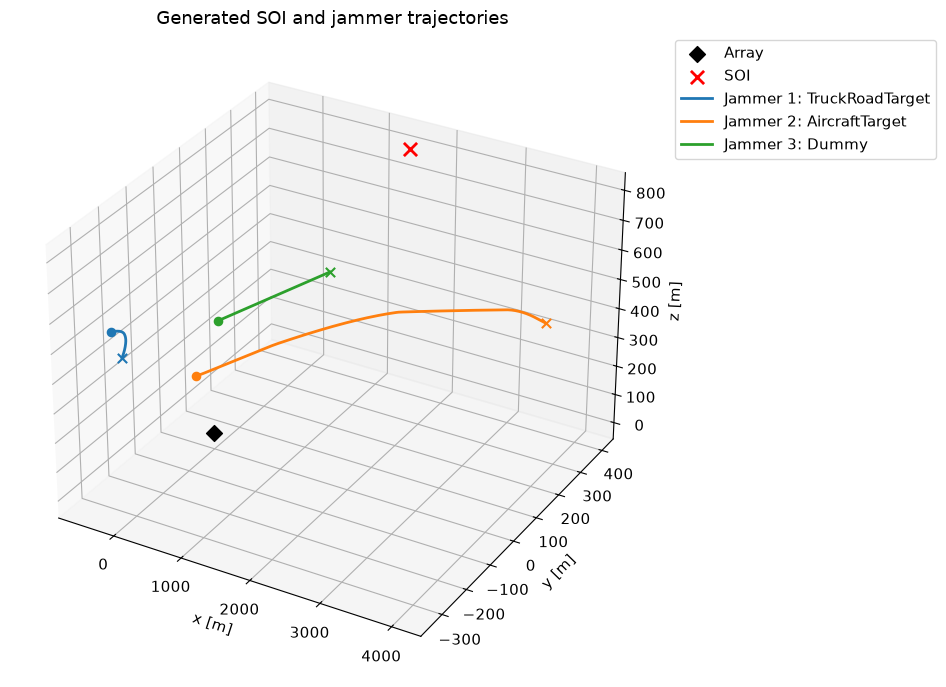

In [4]:
# ============================================================
# 4. Visualize the physical geometry
# ============================================================

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(*ARRAY_POSITION_M, c="black", marker="D", s=65, label="Array")
ax.scatter(
    *desired_source_position_m,
    c="red",
    marker="x",
    s=90,
    linewidths=2.0,
    label="SOI",
)

for jammer_idx, jammer_data in enumerate(scenario["jammers"], start=1):
    positions = jammer_data["position"]
    line, = ax.plot(
        positions[:, 0],
        positions[:, 1],
        positions[:, 2],
        linewidth=2.0,
        label=f"Jammer {jammer_idx}: {jammer_data['class_name']}",
    )
    ax.scatter(*positions[0], color=line.get_color(), marker="o", s=35)
    ax.scatter(*positions[-1], color=line.get_color(), marker="x", s=45)

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
ax.set_title("Generated SOI and jammer trajectories")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.tight_layout()
plt.show()

## Perception: MUSIC and multi-target tracking

The tracking configuration is selected automatically from the offline lookup table. For the scenario signature

`1x_aircraft + 1x_dummy + 1x_truck`

the notebook loads `src/tfm/selection/scenario_lookup_table.csv` and calls the same `select_tracking_configuration` helper used by the scenario notebooks. For the supplied table, this signature selects an `IMM` tracker with `hungarian` association. No tracker or association policy is hard-coded for the scenario.

MUSIC uses the known number of jammer sources in this controlled validation. The SOI is fixed and known and is therefore excluded from the MUSIC/Tracker chain.

In [5]:
# ============================================================
# 5. Create the MUSIC scan manifold and lookup-validated MTT
# ============================================================

selection_csv_path = (
    PROJECT_ROOT
    / "src"
    / "tfm"
    / "selection"
    / "scenario_lookup_table.csv"
)
print(f"Loading selection lookup from: {selection_csv_path}")
selection_lookup = load_selection_lookup(selection_csv_path)

target_signature = build_target_signature(jammers)
selection_result = select_tracking_configuration(
    target_signature=target_signature,
    selection_lookup=selection_lookup,
)
TRACKER_TYPE = selection_result["recommended_tracker"]
ASSOCIATION_POLICY = selection_result["recommended_policy"]

print(f"Selection lookup loaded with {len(selection_lookup)} entries.")
print(f"Target signature: {target_signature}")
print(f"Selected tracker: {TRACKER_TYPE}")
print(f"Selected association policy: {ASSOCIATION_POLICY}")

theta_grid_deg = np.arange(
    0.0,
    90.0 + 0.5 * THETA_STEP_DEG,
    THETA_STEP_DEG,
)
phi_grid_deg = np.arange(0.0, 360.0, PHI_STEP_DEG)

theta_mesh, phi_mesh = np.meshgrid(
    theta_grid_deg,
    phi_grid_deg,
    indexing="ij",
)
scan_angles = np.column_stack((theta_mesh.ravel(), phi_mesh.ravel()))

steering_vectors_scan = np.column_stack(
    [
        get_steering_vector(
            element_positions=array.element_positions,
            wavenumber_k=array.k_num,
            direction=(float(theta_deg), float(phi_deg)),
        )
        for theta_deg, phi_deg in scan_angles
    ]
).astype(np.complex128)

CV_Q_NOISE_STD = 0.003
CA_Q_NOISE_STD = 0.05
R_NOISE_STD = 0.05
IMM_TRANSITION_MATRIX = np.array(
    [[0.98, 0.02], [0.02, 0.98]],
    dtype=float,
)
IMM_INITIAL_MODE_PROBABILITIES = np.array([0.5, 0.5], dtype=float)
IMM_CV_TO_CA_ACCEL_VAR = 0.5


def tracker_factory():
    """Build the tracker selected by the scenario lookup table."""

    if TRACKER_TYPE == "CV":
        return UnitVectorCVKalmanTracker(
            dt=TRACKER_DT_S,
            q_noise_std=CV_Q_NOISE_STD,
            r_noise_std=R_NOISE_STD,
        )

    if TRACKER_TYPE == "CA":
        return UnitVectorCAKalmanTracker(
            dt=TRACKER_DT_S,
            q_noise_std=CA_Q_NOISE_STD,
            r_noise_std=R_NOISE_STD,
        )

    if TRACKER_TYPE == "IMM":
        return IMMKalmanTracker(
            dt=TRACKER_DT_S,
            cv_q_noise_std=CV_Q_NOISE_STD,
            ca_q_noise_std=CA_Q_NOISE_STD,
            r_noise_std=R_NOISE_STD,
            transition_matrix=IMM_TRANSITION_MATRIX,
            initial_mode_probabilities=IMM_INITIAL_MODE_PROBABILITIES,
            cv_to_ca_accel_var=IMM_CV_TO_CA_ACCEL_VAR,
        )

    raise ValueError(f"Unsupported TRACKER_TYPE: {TRACKER_TYPE}")


if ASSOCIATION_POLICY == "greedy":
    association_policy = GreedyNearestNeighbor()
elif ASSOCIATION_POLICY == "priority":
    association_policy = PriorityNearestNeighbor()
elif ASSOCIATION_POLICY == "hungarian":
    association_policy = HungarianNearestNeighbor()
elif ASSOCIATION_POLICY == "mahalanobis_hungarian":
    association_policy = MahalanobisHungarian()
elif ASSOCIATION_POLICY == "scorebased_hungarian":
    association_policy = ScoreBasedHungarian()
else:
    raise ValueError(
        f"Unsupported ASSOCIATION_POLICY: {ASSOCIATION_POLICY}"
    )


multi_tracker = MultiTargetTracker(
    tracker_factory=tracker_factory,
    association_policy=association_policy,
    distance_threshold=0.3,
    confirm_hits=2,
    max_misses=8,
    tentative_max_misses=5,
)

print(f"MUSIC scan directions: {len(scan_angles):,}")
print(f"Scan manifold shape: {steering_vectors_scan.shape}")
print(f"Tracker configuration: {TRACKER_TYPE} + {ASSOCIATION_POLICY}")
print(f"Tracker update period: {TRACKER_DT_S:.1f} s")

Loading selection lookup from: C:\Users\rodri\TFM_demo\src\tfm\selection\scenario_lookup_table.csv
Selection lookup loaded with 56 entries.
Target signature: 1x_aircraft + 1x_dummy + 1x_truck
Selected tracker: IMM
Selected association policy: hungarian
MUSIC scan directions: 16,380
Scan manifold shape: (36, 16380)
Tracker configuration: IMM + hungarian
Tracker update period: 0.3 s


In [6]:
# ============================================================
# 6. Perception helpers
# ============================================================

perception_rng = np.random.default_rng(GLOBAL_SEED)


def visible_direction_deg(jammer_data, physical_idx):
    """Read one scenario DOA and apply the project's visible-sector rule."""

    theta_deg = float(np.rad2deg(jammer_data["doa"]["theta"][physical_idx]))
    phi_deg = float(np.rad2deg(jammer_data["doa"]["phi"][physical_idx]))

    if theta_deg < 0.0:
        theta_deg = -theta_deg
        phi_deg += 180.0

    theta_deg = min(theta_deg, 90.0)
    phi_deg = phi_deg % 360.0

    return theta_deg, phi_deg


def generate_music_measurements(physical_idx):
    """Generate jammer snapshots and extract separated MUSIC peaks."""

    snapshots = np.zeros(
        (NUM_ELEMENTS, NUM_SNAPSHOTS),
        dtype=np.complex128,
    )

    for jammer_data in scenario["jammers"]:
        direction_deg = visible_direction_deg(jammer_data, physical_idx)
        steering_vector = get_steering_vector(
            element_positions=array.element_positions,
            wavenumber_k=array.k_num,
            direction=direction_deg,
        ).astype(np.complex128)

        source_samples = np.sqrt(jammer_data["power"] / 2.0) * (
            perception_rng.standard_normal(NUM_SNAPSHOTS)
            + 1j * perception_rng.standard_normal(NUM_SNAPSHOTS)
        )
        snapshots += steering_vector[:, None] * source_samples[None, :]

    noise_samples = np.sqrt(NOISE_POWER / 2.0) * (
        perception_rng.standard_normal((NUM_ELEMENTS, NUM_SNAPSHOTS))
        + 1j * perception_rng.standard_normal((NUM_ELEMENTS, NUM_SNAPSHOTS))
    )
    snapshots += noise_samples

    covariance_matrix = snapshots @ snapshots.conj().T / NUM_SNAPSHOTS
    regularization = (
        MUSIC_REG_FACTOR
        * np.trace(covariance_matrix).real
        / covariance_matrix.shape[0]
    )
    covariance_regularized = covariance_matrix + regularization * np.eye(
        covariance_matrix.shape[0],
        dtype=np.complex128,
    )

    _, spatial_spectrum = doa_music(
        covariance_matrix=covariance_regularized,
        steering_vectors=steering_vectors_scan,
        scan_angles=scan_angles,
        num_signals=len(scenario["jammers"]),
    )

    doa_peaks = extract_top_doa_peaks(
        spectrum_flat=spatial_spectrum,
        theta_grid_deg=theta_grid_deg,
        phi_grid_deg=phi_grid_deg,
        num_peaks=len(scenario["jammers"]),
        guard_theta_bins=1,
        guard_phi_bins=3,
        min_relative_power=MIN_RELATIVE_POWER,
    )

    return [
        {"theta": float(theta), "phi": float(phi)}
        for theta, phi, _ in doa_peaks
    ]


def snapshot_confirmed_tracks():
    """Export confirmed MTT position and velocity states."""

    result = []

    for track in multi_tracker.get_confirmed_tracks():
        theta_deg, phi_deg = track.get_angles()
        result.append(
            {
                "track_id": int(track.track_id),
                "theta_deg": float(theta_deg),
                "phi_deg": float(phi_deg),
                "u": track.get_unit_vector().flatten().astype(float),
                "du_per_s": (
                    track.tracker.get_velocity_vector().flatten().astype(float)
                ),
            }
        )

    return result

In [7]:
# ============================================================
# 7. Run MUSIC + MTT over the complete scenario
# ============================================================

measurement_history = []
confirmed_track_history = []

for measurement_idx, physical_idx in enumerate(MUSIC_INDICES):
    measurements = generate_music_measurements(physical_idx)
    multi_tracker.step(measurements)
    confirmed_tracks = snapshot_confirmed_tracks()

    measurement_history.append(measurements)
    confirmed_track_history.append(
        {
            "measurement_idx": int(measurement_idx),
            "physical_idx": int(physical_idx),
            "time_s": float(physical_idx * SCENARIO_DT_S),
            "tracks": confirmed_tracks,
        }
    )

track_count = np.array(
    [len(item["tracks"]) for item in confirmed_track_history],
    dtype=int,
)

print(f"MUSIC/MTT updates: {len(MUSIC_INDICES)}")
print(f"Maximum confirmed tracks: {track_count.max()}")
print(
    "Fraction with correct confirmed cardinality: "
    f"{np.mean(track_count == len(jammers)):.1%}"
)

MUSIC/MTT updates: 100
Maximum confirmed tracks: 3
Fraction with correct confirmed cardinality: 55.0%


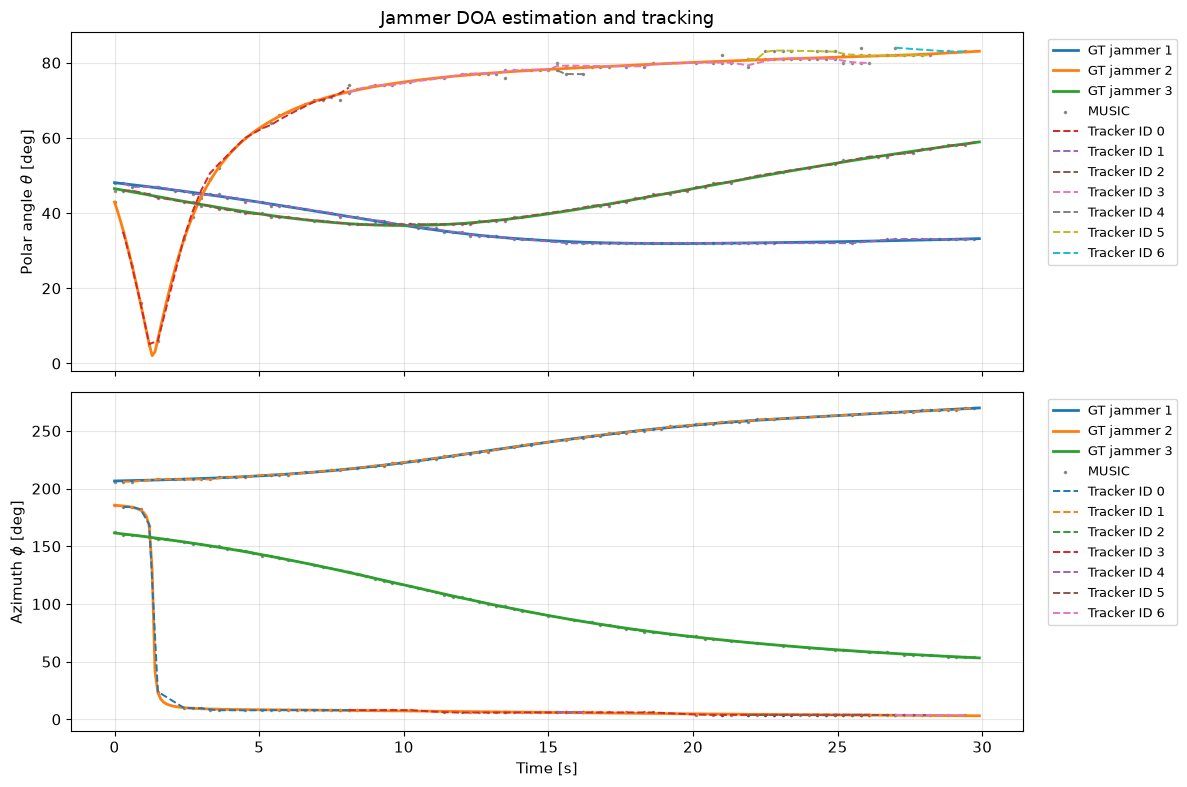

In [8]:
# ============================================================
# 8. Plot true jammer DOAs, MUSIC detections, and confirmed tracks
# ============================================================

fig, (ax_theta, ax_phi) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for jammer_idx, jammer_data in enumerate(scenario["jammers"], start=1):
    true_directions = np.array(
        [visible_direction_deg(jammer_data, idx) for idx in range(NUM_SCENARIO_STEPS)]
    )
    line, = ax_theta.plot(
        time_s,
        true_directions[:, 0],
        linewidth=2.0,
        label=f"GT jammer {jammer_idx}",
    )
    ax_phi.plot(
        time_s,
        true_directions[:, 1],
        linewidth=2.0,
        color=line.get_color(),
        label=f"GT jammer {jammer_idx}",
    )

music_times = []
music_theta = []
music_phi = []
for update, measurements in zip(confirmed_track_history, measurement_history):
    for measurement in measurements:
        music_times.append(update["time_s"])
        music_theta.append(measurement["theta"])
        music_phi.append(measurement["phi"])

ax_theta.scatter(
    music_times,
    music_theta,
    marker=".",
    s=10,
    alpha=0.35,
    color="black",
    label="MUSIC",
)
ax_phi.scatter(
    music_times,
    music_phi,
    marker=".",
    s=10,
    alpha=0.35,
    color="black",
    label="MUSIC",
)

all_track_ids = sorted(
    {
        track["track_id"]
        for update in confirmed_track_history
        for track in update["tracks"]
    }
)

for track_id in all_track_ids:
    samples = [
        (update["time_s"], track)
        for update in confirmed_track_history
        for track in update["tracks"]
        if track["track_id"] == track_id
    ]
    ax_theta.plot(
        [sample[0] for sample in samples],
        [sample[1]["theta_deg"] for sample in samples],
        linestyle="--",
        linewidth=1.4,
        label=f"Tracker ID {track_id}",
    )
    ax_phi.plot(
        [sample[0] for sample in samples],
        [sample[1]["phi_deg"] for sample in samples],
        linestyle="--",
        linewidth=1.4,
        label=f"Tracker ID {track_id}",
    )

ax_theta.set_ylabel(r"Polar angle $\theta$ [deg]")
ax_phi.set_ylabel(r"Azimuth $\phi$ [deg]")
ax_phi.set_xlabel("Time [s]")
ax_theta.set_title("Jammer DOA estimation and tracking")
ax_theta.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=9)
ax_phi.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), fontsize=9)
fig.tight_layout()
plt.show()

## Phase 11 Tracker observation and cognitive action

A control instant is selected only after exactly three tracks are confirmed and while a complete 20 s evaluation interval remains. Tracks are ordered by their persistent track IDs. Each active slot contributes

[
[u_x,u_y,u_z,\dot u_x\Delta t/2,\dot u_y\Delta t/2,\dot u_z\Delta t/2,1],
]

with (Delta t=1) s, matching `BeamformingEnvPhase11._build_phase11_state`. Unused slots would be filled with zeros.

In [9]:
# ============================================================
# 9. Select a valid control block and build the Tracker state
# ============================================================

num_hold_samples = int(round(HOLD_DURATION_S / SCENARIO_DT_S))
minimum_tracker_warmup_s = 3.0

valid_control_updates = [
    update
    for update in confirmed_track_history
    if (
        update["time_s"] >= minimum_tracker_warmup_s
        and len(update["tracks"]) == MAX_JAMMERS
        and update["physical_idx"] + num_hold_samples <= NUM_SCENARIO_STEPS
    )
]

if not valid_control_updates:
    raise RuntimeError(
        "No control instant has exactly three confirmed tracks and a complete "
        "20 s interval. Inspect the preceding tracking plot and configuration."
    )

control_update = valid_control_updates[0]
control_physical_idx = control_update["physical_idx"]
control_time_s = control_update["time_s"]
control_tracks = sorted(
    control_update["tracks"],
    key=lambda item: item["track_id"],
)

soi_theta_deg = float(np.rad2deg(scenario["desired"]["doa"]["theta"][0]))
soi_phi_deg = float(np.rad2deg(scenario["desired"]["doa"]["phi"][0]))
soi_direction_deg = (soi_theta_deg, soi_phi_deg)
soi_unit_vector = angles_to_unit_vector(soi_theta_deg, soi_phi_deg)


def build_phase11_tracker_observation(soi_u, tracks):
    """Reproduce the unit-vector Phase 11 observation encoding."""

    state = [float(value) for value in soi_u]

    for jammer_slot in range(MAX_JAMMERS):
        if jammer_slot < len(tracks):
            u_jammer = np.asarray(tracks[jammer_slot]["u"], dtype=float)
            u_jammer = u_jammer / np.linalg.norm(u_jammer)

            du_per_s = np.asarray(
                tracks[jammer_slot]["du_per_s"],
                dtype=float,
            )
            du_step_normalized = np.clip(
                du_per_s * POLICY_DT_S / 2.0,
                -1.0,
                1.0,
            )

            state.extend(
                [
                    *u_jammer.tolist(),
                    *du_step_normalized.tolist(),
                    1.0,
                ]
            )
        else:
            state.extend([0.0] * 7)

    result = np.clip(np.asarray(state, dtype=np.float32), -1.0, 1.0)
    assert result.shape == (OBSERVATION_DIM,)
    assert np.all(np.isfinite(result))
    return result


tracker_observation = build_phase11_tracker_observation(
    soi_unit_vector,
    control_tracks,
)

control_tracks_df = pd.DataFrame(
    [
        {
            "track_id": track["track_id"],
            "theta_deg": track["theta_deg"],
            "phi_deg": track["phi_deg"],
            "u_x": track["u"][0],
            "u_y": track["u"][1],
            "u_z": track["u"][2],
            "du_x_per_s": track["du_per_s"][0],
            "du_y_per_s": track["du_per_s"][1],
            "du_z_per_s": track["du_per_s"][2],
        }
        for track in control_tracks
    ]
)

print(f"Control time: {control_time_s:.1f} s")
print(f"Evaluation interval: {HOLD_DURATION_S:.1f} s")
print(f"Observation shape: {tracker_observation.shape}")
display(control_tracks_df)

Control time: 3.0 s
Evaluation interval: 20.0 s
Observation shape: (24,)


,track_id,theta_deg,phi_deg,u_x,u_y,u_z,du_x_per_s,du_y_per_s,du_z_per_s
0,0,46.118114,9.637940,0.710597,0.120673,0.693174,0.296903,0.035724,-0.310584
1,1,44.894454,207.981614,-0.623293,-0.331154,0.708408,0.014518,0.011502,0.018150
2,2,42.203852,151.618863,-0.591027,0.319316,0.740759,0.035270,0.026339,0.016787


In [10]:
# ============================================================
# 10. Load the selected Phase 11 SAC agent and infer one action
# ============================================================

model = SAC.load(str(MODEL_PATH), device="auto")

assert model.observation_space.shape == (OBSERVATION_DIM,)
assert model.action_space.shape == (ACTION_DIM,)

action, _ = model.predict(
    tracker_observation,
    deterministic=True,
)
action = np.asarray(action, dtype=np.float32).reshape(-1)

assert action.shape == (ACTION_DIM,)
assert np.all(np.isfinite(action))

print(f"Loaded policy: {model.policy.__class__.__name__}")
print(f"Training timesteps stored in model: {model.num_timesteps:,}")
print(f"Action shape: {action.shape}")
print(f"Action range: [{action.min():.4f}, {action.max():.4f}]")

Loaded policy: SACPolicy
Training timesteps stored in model: 1,200,000
Action shape: (15,)
Action range: [-0.7449, 0.9632]


In [11]:
# ============================================================
# 11. Decode the action and generate predictive nulling weights
# ============================================================

def project_to_visible_unit_vector(vector):
    """Apply the same normalization and visible-hemisphere rule as Phase 11."""

    vector = np.asarray(vector, dtype=float).reshape(3)
    norm = float(np.linalg.norm(vector))

    if not np.isfinite(norm) or norm < 1e-12:
        vector = np.array([0.0, 0.0, 1.0], dtype=float)
    else:
        vector = vector / norm

    if vector[2] < 0.0:
        vector[2] = abs(vector[2])
        vector = vector / np.linalg.norm(vector)

    return vector


def deduplicate_directions(directions_deg):
    """Remove numerically identical physical zero directions."""

    unique = []

    for candidate in directions_deg:
        candidate_u = angles_to_unit_vector(*candidate)
        if not any(
            np.allclose(candidate_u, angles_to_unit_vector(*existing), atol=1e-10)
            for existing in unique
        ):
            unique.append((float(candidate[0]), float(candidate[1])))

    return unique


def phase11_action_to_weights(raw_action, tracks):
    """Apply the implemented Phase 11 direction-plus-width semantics."""

    raw_action = np.asarray(raw_action, dtype=np.float32).reshape(ACTION_DIM)
    predicted_soi_u = project_to_visible_unit_vector(raw_action[:3])
    predicted_soi_direction = unit_vector_to_angles(predicted_soi_u)

    predicted_jammer_directions = []
    deltas = []
    null_horizons_steps = []
    zero_triplets = []

    for jammer_slot in range(MAX_JAMMERS):
        base_idx = 3 + 4 * jammer_slot
        predicted_jammer_u = project_to_visible_unit_vector(
            raw_action[base_idx : base_idx + 3]
        )
        delta = float(np.clip(raw_action[base_idx + 3], 0.0, 1.0))

        predicted_jammer_directions.append(
            unit_vector_to_angles(predicted_jammer_u)
        )
        deltas.append(delta)

        if jammer_slot < len(tracks):
            horizon_steps = delta * MAX_NULL_HORIZON_STEPS
            du_per_policy_step = (
                np.asarray(tracks[jammer_slot]["du_per_s"], dtype=float)
                * POLICY_DT_S
            )

            u_minus = project_to_visible_unit_vector(
                predicted_jammer_u - horizon_steps * du_per_policy_step
            )
            u_center = predicted_jammer_u
            u_plus = project_to_visible_unit_vector(
                predicted_jammer_u + horizon_steps * du_per_policy_step
            )

            triplet = (
                unit_vector_to_angles(u_minus),
                unit_vector_to_angles(u_center),
                unit_vector_to_angles(u_plus),
            )
            zero_triplets.append(triplet)
            null_horizons_steps.append(horizon_steps)

    zero_directions = deduplicate_directions(
        [direction for triplet in zero_triplets for direction in triplet]
    )

    weights = target_or_zero_weights(
        element_positions=array.element_positions,
        wavenumber_k=array.k_num,
        target_directions=[predicted_soi_direction],
        zero_directions=zero_directions,
        diagonal_loading=NULLING_DIAGONAL_LOADING,
        use_pinv=False,
    )

    info = {
        "predicted_soi_direction_deg": predicted_soi_direction,
        "predicted_jammer_directions_deg": predicted_jammer_directions,
        "deltas": np.asarray(deltas),
        "null_horizons_steps": np.asarray(null_horizons_steps),
        "zero_triplets_deg": zero_triplets,
        "zero_directions_unique_deg": zero_directions,
    }

    return weights, info


agent_weights_raw, agent_action_info = phase11_action_to_weights(
    action,
    control_tracks,
)

action_summary_df = pd.DataFrame(
    [
        {
            "jammer_slot": jammer_slot + 1,
            "predicted_theta_deg": (
                agent_action_info["predicted_jammer_directions_deg"][jammer_slot][0]
            ),
            "predicted_phi_deg": (
                agent_action_info["predicted_jammer_directions_deg"][jammer_slot][1]
            ),
            "delta": agent_action_info["deltas"][jammer_slot],
            "null_horizon_steps": (
                agent_action_info["null_horizons_steps"][jammer_slot]
            ),
        }
        for jammer_slot in range(MAX_JAMMERS)
    ]
)

print("Predicted SOI direction [deg]:", agent_action_info["predicted_soi_direction_deg"])
print("Unique zero constraints:", len(agent_action_info["zero_directions_unique_deg"]))
display(action_summary_df)

Predicted SOI direction [deg]: (62.22268311182675, 14.866822594782844)
Unique zero constraints: 9


,jammer_slot,predicted_theta_deg,predicted_phi_deg,delta,null_horizon_steps
0,1,46.101482,9.159844,0.207568,4.151357
1,2,45.315410,206.601489,0.411622,8.232446
2,3,42.352520,152.187274,0.376975,7.539504


## Beamformer comparison over the held 20 s block

Five methods are evaluated on the same ground-truth trajectory:

- **Steering**: SOI-only conventional beamforming, held for 20 s.
- **Tracker nulling K=20**: one zero at each tracked jammer direction, held for 20 s.
- **Tracker MVDR K=20**: MVDR built from tracked jammer directions at block start, held for 20 s.
- **Phase 11 DRL K=20**: the policy's predicted directions and motion-aligned zero triplets, held for 20 s.
- **Instantaneous MVDR Oracle**: true jammer directions and a new MVDR solution at every 0.1 s sample.

Every weight vector is rescaled to unit total weight power before evaluation. This does not alter SINR or relative array-response metrics, but makes the compared weight powers explicit and identical.

In [12]:
# ============================================================
# 12. Build classical baselines and evaluate all beamformers
# ============================================================

def normalize_total_weight_power(weights, target_power=1.0):
    """Rescale a complex weight vector to a fixed total power."""

    weights = np.asarray(weights, dtype=np.complex128).reshape(-1)
    current_power = float(np.sum(np.abs(weights) ** 2))

    if not np.isfinite(current_power) or current_power <= 1e-15:
        raise ValueError("Cannot normalize a zero or invalid weight vector.")

    return weights * np.sqrt(float(target_power) / current_power)


def build_interference_noise_covariance(jammer_directions_deg):
    """Build the narrow-band interference-plus-noise covariance."""

    covariance = NOISE_POWER * np.eye(NUM_ELEMENTS, dtype=np.complex128)

    for jammer_direction, jammer_power in zip(
        jammer_directions_deg,
        JAMMER_POWERS,
    ):
        jammer_sv = get_steering_vector(
            element_positions=array.element_positions,
            wavenumber_k=array.k_num,
            direction=jammer_direction,
        ).astype(np.complex128).reshape(NUM_ELEMENTS)
        covariance += jammer_power * np.outer(jammer_sv, jammer_sv.conj())

    covariance += MVDR_DIAGONAL_LOADING * np.eye(
        NUM_ELEMENTS,
        dtype=np.complex128,
    )
    return covariance


tracker_directions_deg = [
    (track["theta_deg"], track["phi_deg"])
    for track in control_tracks
]

steering_weights_raw = steering_weights(
    element_positions=array.element_positions,
    wavenumber_k=array.k_num,
    direction=soi_direction_deg,
)

tracker_nulling_weights_raw = target_or_zero_weights(
    element_positions=array.element_positions,
    wavenumber_k=array.k_num,
    target_directions=[soi_direction_deg],
    zero_directions=tracker_directions_deg,
    diagonal_loading=NULLING_DIAGONAL_LOADING,
    use_pinv=False,
)

tracker_mvdr_covariance = build_interference_noise_covariance(
    tracker_directions_deg
)
tracker_mvdr_weights_raw = mvdr_weights(
    R_xx=tracker_mvdr_covariance,
    element_positions=array.element_positions,
    wavenumber_k=array.k_num,
    target_direction=soi_direction_deg,
)

held_weights = {
    "Steering": normalize_total_weight_power(steering_weights_raw),
    "Tracker nulling K=20": normalize_total_weight_power(
        tracker_nulling_weights_raw
    ),
    "Tracker MVDR K=20": normalize_total_weight_power(
        tracker_mvdr_weights_raw
    ),
    "Phase 11 DRL K=20": normalize_total_weight_power(agent_weights_raw),
}

evaluation_indices = np.arange(
    control_physical_idx,
    control_physical_idx + num_hold_samples,
    dtype=int,
)

metric_rows = []

for physical_idx in evaluation_indices:
    jammer_directions_true_deg = [
        visible_direction_deg(jammer_data, physical_idx)
        for jammer_data in scenario["jammers"]
    ]

    weights_at_step = dict(held_weights)

    oracle_covariance = build_interference_noise_covariance(
        jammer_directions_true_deg
    )
    oracle_weights_raw = mvdr_weights(
        R_xx=oracle_covariance,
        element_positions=array.element_positions,
        wavenumber_k=array.k_num,
        target_direction=soi_direction_deg,
    )
    weights_at_step["Instantaneous MVDR Oracle"] = (
        normalize_total_weight_power(oracle_weights_raw)
    )

    for method_name, weights in weights_at_step.items():
        sinr_db = compute_sinr(
            weights=weights,
            element_positions=array.element_positions,
            wavenumber_k=array.k_num,
            target_direction=soi_direction_deg,
            target_power=DESIRED_POWER,
            jammers_directions=jammer_directions_true_deg,
            jammers_powers=JAMMER_POWERS,
            noise_power=NOISE_POWER,
        )

        soi_gain_linear = compute_array_factor(
            weights,
            array.element_positions,
            array.k_num,
            soi_direction_deg,
        ) ** 2
        jammer_gains_linear = np.array(
            [
                compute_array_factor(
                    weights,
                    array.element_positions,
                    array.k_num,
                    direction,
                ) ** 2
                for direction in jammer_directions_true_deg
            ],
            dtype=float,
        )
        leakage = float(
            np.mean(jammer_gains_linear / max(soi_gain_linear, 1e-12))
        )
        null_depth_values_db = [
            evaluate_null_depth(
                weights=weights,
                element_positions=array.element_positions,
                wavenumber_k=array.k_num,
                target_direction=soi_direction_deg,
                null_direction=direction,
            )
            for direction in jammer_directions_true_deg
        ]

        metric_rows.append(
            {
                "method": method_name,
                "physical_idx": int(physical_idx),
                "time_s": float(physical_idx * SCENARIO_DT_S),
                "sinr_db": float(sinr_db),
                "soi_gain_linear": float(soi_gain_linear),
                "jammer_leakage": leakage,
                "mean_null_depth_db": float(np.mean(null_depth_values_db)),
                "weight_power": float(np.sum(np.abs(weights) ** 2)),
            }
        )

metrics_df = pd.DataFrame(metric_rows)

steering_reference_gain_db = 10.0 * np.log10(
    metrics_df.loc[
        metrics_df["method"] == "Steering",
        "soi_gain_linear",
    ].iloc[0]
)

summary_df = (
    metrics_df.groupby("method", sort=False)
    .agg(
        mean_sinr_db=("sinr_db", "mean"),
        min_sinr_db=("sinr_db", "min"),
        p05_sinr_db=("sinr_db", lambda values: values.quantile(0.05)),
        mean_soi_gain_linear=("soi_gain_linear", "mean"),
        mean_jammer_leakage=("jammer_leakage", "mean"),
        mean_null_depth_db=("mean_null_depth_db", "mean"),
        mean_weight_power=("weight_power", "mean"),
    )
    .reset_index()
)
summary_df["soi_gain_loss_db"] = (
    steering_reference_gain_db
    - 10.0 * np.log10(summary_df["mean_soi_gain_linear"])
).clip(lower=0.0)

numeric_columns = summary_df.select_dtypes(include=[np.number]).columns
summary_df[numeric_columns] = summary_df[numeric_columns].round(4)

display(summary_df)

,method,mean_sinr_db,min_sinr_db,p05_sinr_db,mean_soi_gain_linear,mean_jammer_leakage,mean_null_depth_db,mean_weight_power,soi_gain_loss_db
0,Steering,3.3963,1.2986,1.3860,36.0000,0.1589,27.6098,1.0,0.0000
1,Tracker nulling K=20,2.8931,1.1148,1.1489,21.8338,0.1931,22.8205,1.0,2.1717
2,Tracker MVDR K=20,2.8932,1.1148,1.1489,21.8347,0.1931,22.8214,1.0,2.1716
3,Phase 11 DRL K=20,15.5022,7.3246,7.8158,9.8581,0.0179,26.0344,1.0,5.6251
4,Instantaneous MVDR Oracle,42.5754,39.7517,39.9516,18.8331,0.0000,inf,1.0,2.8138


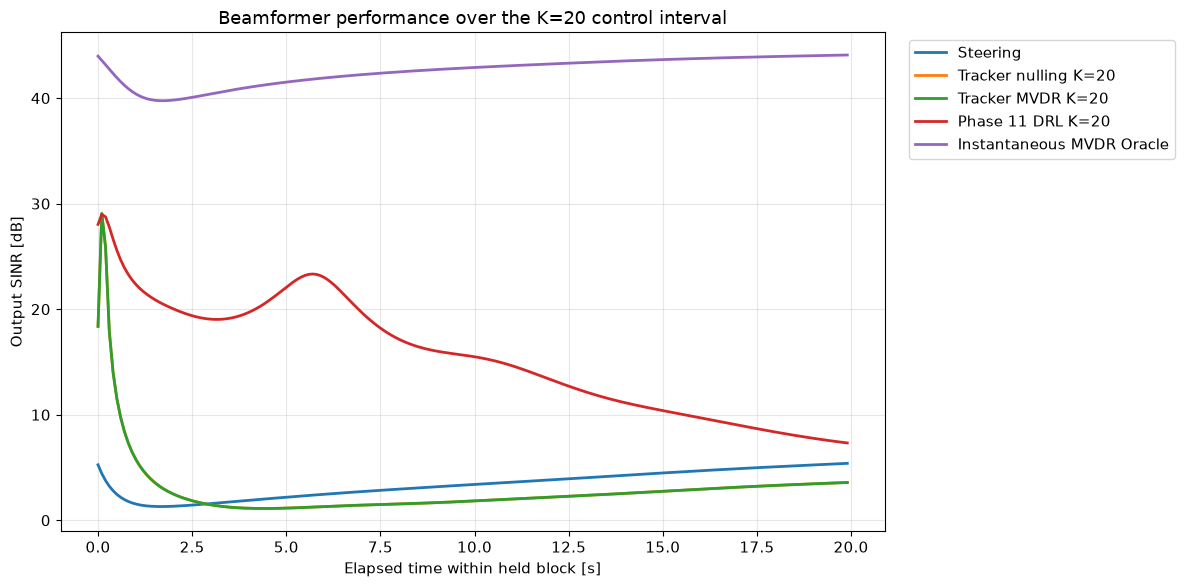

In [13]:
# ============================================================
# 13. SINR evolution over the common 20 s interval
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

for method_name, method_data in metrics_df.groupby("method", sort=False):
    ax.plot(
        method_data["time_s"] - control_time_s,
        method_data["sinr_db"],
        linewidth=2.0,
        label=method_name,
    )

ax.set_xlabel("Elapsed time within held block [s]")
ax.set_ylabel("Output SINR [dB]")
ax.set_title("Beamformer performance over the K=20 control interval")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.tight_layout()
plt.show()

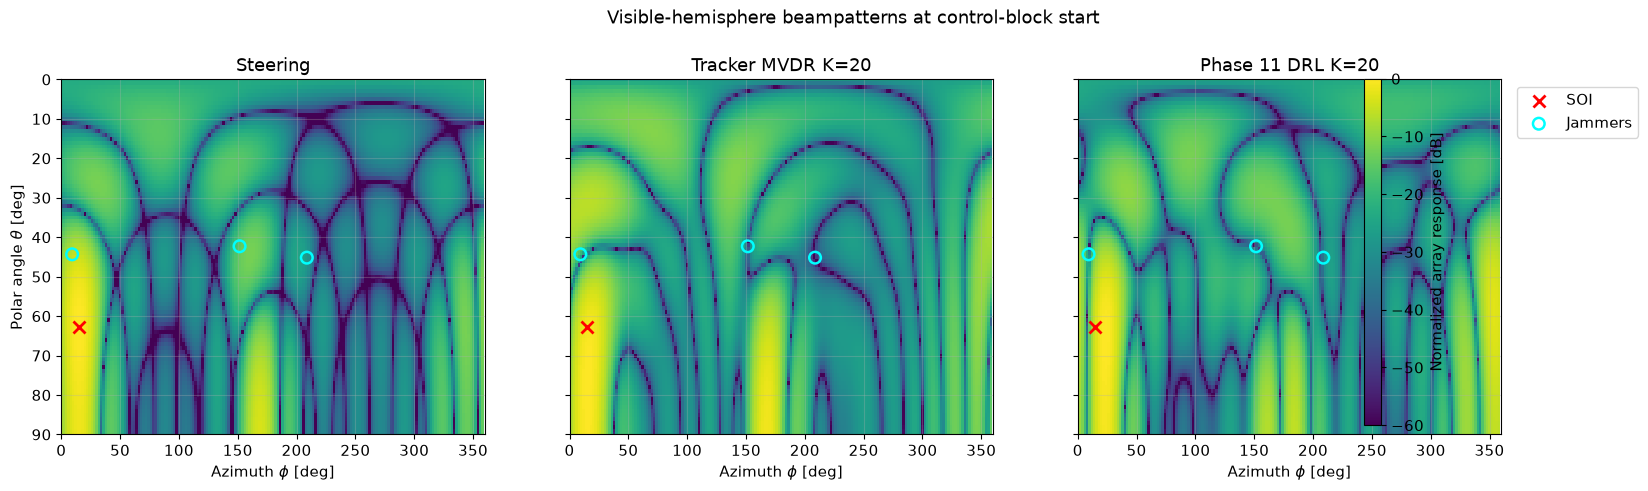

In [14]:
# ============================================================
# 14. Visible-hemisphere beampattern comparison at block start
# ============================================================

pattern_methods = {
    "Steering": held_weights["Steering"],
    "Tracker MVDR K=20": held_weights["Tracker MVDR K=20"],
    "Phase 11 DRL K=20": held_weights["Phase 11 DRL K=20"],
}

control_true_jammer_directions = [
    visible_direction_deg(jammer_data, control_physical_idx)
    for jammer_data in scenario["jammers"]
]

fig, axes = plt.subplots(
    1,
    len(pattern_methods),
    figsize=(18, 5),
    sharex=True,
    sharey=True,
)

for ax, (method_name, weights) in zip(axes, pattern_methods.items()):
    pattern_linear, theta_grid_rad, phi_grid_rad = compute_beampattern(
        weights=weights,
        element_positions=array.element_positions,
        wavenumber_k=array.k_num,
        theta_res=1.0,
        phi_res=2.0,
        normalize=True,
    )
    visible_mask = np.rad2deg(theta_grid_rad[:, 0]) <= 90.0
    pattern_db = 20.0 * np.log10(np.maximum(pattern_linear, 1e-4))

    image = ax.pcolormesh(
        np.rad2deg(phi_grid_rad[visible_mask]),
        np.rad2deg(theta_grid_rad[visible_mask]),
        pattern_db[visible_mask],
        shading="auto",
        cmap="viridis",
        vmin=-60.0,
        vmax=0.0,
    )
    ax.scatter(
        soi_phi_deg,
        soi_theta_deg,
        color="red",
        marker="x",
        s=75,
        linewidths=2.0,
        label="SOI",
        zorder=5,
    )
    ax.scatter(
        [direction[1] for direction in control_true_jammer_directions],
        [direction[0] for direction in control_true_jammer_directions],
        facecolors="none",
        edgecolors="cyan",
        marker="o",
        s=70,
        linewidths=1.8,
        label="Jammers",
        zorder=5,
    )
    ax.set_title(method_name)
    ax.set_xlabel(r"Azimuth $\phi$ [deg]")
    ax.set_xlim(0.0, 360.0)
    ax.set_ylim(90.0, 0.0)

axes[0].set_ylabel(r"Polar angle $\theta$ [deg]")
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
colorbar = fig.colorbar(image, ax=axes, shrink=0.90, pad=0.08)
colorbar.set_label("Normalized array response [dB]")
fig.suptitle("Visible-hemisphere beampatterns at control-block start")
fig.subplots_adjust(left=0.06, right=0.86, bottom=0.13, top=0.84, wspace=0.20)
plt.show()

## Native Phase 11 environment compatibility check

The preceding cells expose every stage of the external ScenarioGenerator → MUSIC → Tracker → agent chain. The next cell independently runs the trained model through its original Gymnasium interface. It verifies the saved observation/action spaces and lets `BeamformingEnvPhase11` perform its own scenario generation, predictive-zero construction, (K=20) hold, physical metrics, and reward aggregation.

In [15]:
# ============================================================
# 15. One native BeamformingEnvPhase11 rollout
# ============================================================

native_env = BeamformingEnvPhase11(
    array=Phased_Array_NB(
        num_rows=NUM_ROWS,
        num_cols=NUM_COLS,
        carrier_freq=CARRIER_FREQUENCY_HZ,
        normalize_power=True,
    ),
    array_position=ARRAY_POSITION_M,
    desired_power=DESIRED_POWER,
    noise_power=NOISE_POWER,
    max_jammers=MAX_JAMMERS,
    num_active_jammers=3,
    active_jammers_choices=[3],
    jammer_powers=JAMMER_POWERS,
    observation_mode="unit_vector",
    action_mode="unit_vector",
    weight_hold_steps=WEIGHT_HOLD_STEPS,
    episode_length_physical_steps=WEIGHT_HOLD_STEPS,
    dt=POLICY_DT_S,
    min_source_distance_m=50.0,
    min_target_jammer_separation_deg=5.0,
    max_null_horizon_steps=None,
    nulling_diagonal_loading=NULLING_DIAGONAL_LOADING,
    nulling_use_pinv=False,
    mvdr_diagonal_loading=MVDR_DIAGONAL_LOADING,
)

native_observation, native_reset_info = native_env.reset(seed=GLOBAL_SEED)
native_action, _ = model.predict(native_observation, deterministic=True)
(
    native_next_observation,
    native_reward,
    native_terminated,
    native_truncated,
    native_info,
) = native_env.step(native_action)

assert native_observation.shape == (OBSERVATION_DIM,)
assert np.asarray(native_action).reshape(-1).shape == (ACTION_DIM,)
assert np.all(np.isfinite(native_next_observation))
assert np.isfinite(native_reward)

native_summary = pd.Series(
    {
        "active_jammers": native_info["num_active_jammers"],
        "physical_steps_in_block": native_info["num_block_steps"],
        "reward": native_reward,
        "mean_sinr_db": native_info["sinr_db"],
        "mean_reference_sinr_db": native_info["reference_sinr_db"],
        "mean_sinr_loss_db": native_info["sinr_loss_db"],
        "mean_soi_gain_loss_db": native_info["soi_gain_loss_db"],
        "mean_jammer_leakage": native_info["jammer_leakage_loss"],
        "null_horizons_steps": native_info["null_horizons_steps"],
        "unique_zero_directions": native_info["num_zero_directions_unique"],
        "terminated": native_terminated,
        "truncated": native_truncated,
    },
    name="value",
)

display(native_summary.to_frame())
native_env.close()

print("Native model/environment compatibility check passed.")

,value
active_jammers,3
physical_steps_in_block,20
reward,-0.718473
mean_sinr_db,30.655649
mean_reference_sinr_db,45.437266
mean_sinr_loss_db,14.781618
mean_soi_gain_loss_db,0.18995
mean_jammer_leakage,0.002754
null_horizons_steps,"[11.404379606246948, 9.557151794433594, 7.6135..."
unique_zero_directions,7


Native model/environment compatibility check passed.


## Using agents from the other development phases

A checkpoint is not a drop-in replacement for the Phase 11 K=20 model. Each phase changes one or more parts of the contract between the policy and the physical system: the Stable-Baselines3 algorithm, environment class, observation layout, action decoder, jammer distribution, or temporal hold (K). All of those items must be switched together.

The table below contains only checkpoint selections that are explicitly retained in the repository metadata or in the final selection work. No “best” checkpoint is asserted for Phases 5–9 because the available project evidence does not identify one. Those phases are nevertheless documented immediately afterwards so that a checkpoint can be connected safely once it has been selected from its own metadata and evaluation results.

In [16]:
# ============================================================
# 16. Verified retained-checkpoint catalogue and safe loader
# ============================================================

from stable_baselines3 import PPO, SAC, TD3


RETAINED_AGENT_CATALOG = [
    {
        "phase": "1",
        "agent_id": "phase_1_agent_0",
        "algorithm": "TD3",
        "environment": "BeamformingEnv + Phase 1 action adapter",
        "observation_dim": 11,
        "action_dim": 2,
        "K": None,
        "model_path": (
            "simulation/drl_agent/saved_agents/phase_1/"
            "phase_1_agent_0.zip"
        ),
    },
    {
        "phase": "2",
        "agent_id": "phase2_agent_55_5",
        "algorithm": "SAC",
        "environment": "BeamformingEnv",
        "observation_dim": 15,
        "action_dim": 3,
        "K": None,
        "model_path": (
            "simulation/drl_agent/saved_agents/phase_2/"
            "phase2_agent_55_5.zip"
        ),
    },
    {
        "phase": "3",
        "agent_id": "phase3_grid_agent_012",
        "algorithm": "SAC",
        "environment": "BeamformingEnvPhase3",
        "observation_dim": 15,
        "action_dim": 6,
        "K": None,
        "model_path": (
            "simulation/drl_agent/saved_agents/phase_3/"
            "reward_grid_nulling_mvdr/phase3_grid_agent_012.zip"
        ),
    },
    {
        "phase": "4",
        "agent_id": "phase4_agent_finetuned_006",
        "algorithm": "SAC",
        "environment": "BeamformingEnvPhase4",
        "observation_dim": 15,
        "action_dim": 12,
        "K": None,
        "model_path": (
            "simulation/drl_agent/saved_agents/phase_4/"
            "finetuned_agents/phase4_agent_finetuned_006.zip"
        ),
    },
    {
        "phase": "10",
        "agent_id": "phase10_agent_symmetric_real_imag_K1_mixed_011",
        "algorithm": "PPO",
        "environment": "BeamformingEnvPhase10",
        "observation_dim": 15,
        "action_dim": 36,
        "K": 1,
        "model_path": (
            "simulation/drl_agent/saved_agents/phase_10/"
            "symmetric_real_imag_ppo/"
            "phase10_agent_symmetric_real_imag_K1_mixed_011.zip"
        ),
    },
    {
        "phase": "10",
        "agent_id": "phase10_agent_symmetric_real_imag_K5_mixed_025",
        "algorithm": "PPO",
        "environment": "BeamformingEnvPhase10",
        "observation_dim": 15,
        "action_dim": 36,
        "K": 5,
        "model_path": (
            "simulation/drl_agent/saved_agents/phase_10/"
            "symmetric_real_imag_ppo/"
            "phase10_agent_symmetric_real_imag_K5_mixed_025.zip"
        ),
    },
    {
        "phase": "10",
        "agent_id": "phase10_agent_symmetric_real_imag_K20_mixed_028",
        "algorithm": "PPO",
        "environment": "BeamformingEnvPhase10",
        "observation_dim": 15,
        "action_dim": 36,
        "K": 20,
        "model_path": (
            "simulation/drl_agent/saved_agents/phase_10/"
            "symmetric_real_imag_ppo/"
            "phase10_agent_symmetric_real_imag_K20_mixed_028.zip"
        ),
    },
    {
        "phase": "11",
        "agent_id": "phase11_agent_direction_width_K1_mixed_007",
        "algorithm": "SAC",
        "environment": "BeamformingEnvPhase11",
        "observation_dim": 24,
        "action_dim": 15,
        "K": 1,
        "model_path": (
            "simulation/drl_agent/saved_agents/phase_11/"
            "direction_width_sac/"
            "phase11_agent_direction_width_K1_mixed_007.zip"
        ),
    },
    {
        "phase": "11",
        "agent_id": "phase11_agent_direction_width_K5_mixed_001",
        "algorithm": "SAC",
        "environment": "BeamformingEnvPhase11",
        "observation_dim": 24,
        "action_dim": 15,
        "K": 5,
        "model_path": (
            "simulation/drl_agent/saved_agents/phase_11/"
            "direction_width_sac/"
            "phase11_agent_direction_width_K5_mixed_001.zip"
        ),
    },
    {
        "phase": "11",
        "agent_id": "phase11_agent_direction_width_K20_mixed_002",
        "algorithm": "SAC",
        "environment": "BeamformingEnvPhase11",
        "observation_dim": 24,
        "action_dim": 15,
        "K": 20,
        "model_path": (
            "simulation/drl_agent/saved_agents/phase_11/"
            "direction_width_sac/"
            "phase11_agent_direction_width_K20_mixed_002.zip"
        ),
    },
]

ALGORITHM_CLASSES = {"TD3": TD3, "SAC": SAC, "PPO": PPO}


def load_retained_agent(agent_id, device="auto"):
    """Load a retained checkpoint and verify its saved space dimensions."""

    matches = [
        item for item in RETAINED_AGENT_CATALOG
        if item["agent_id"] == agent_id
    ]
    if len(matches) != 1:
        raise KeyError(f"Unknown or ambiguous retained agent: {agent_id}")

    spec = matches[0]
    checkpoint_path = PROJECT_ROOT / spec["model_path"]
    if not checkpoint_path.is_file():
        raise FileNotFoundError(checkpoint_path)

    model_class = ALGORITHM_CLASSES[spec["algorithm"]]
    loaded_model = model_class.load(str(checkpoint_path), device=device)

    assert loaded_model.observation_space.shape == (
        spec["observation_dim"],
    )
    assert loaded_model.action_space.shape == (spec["action_dim"],)

    return loaded_model, spec


retained_agents_df = pd.DataFrame(RETAINED_AGENT_CATALOG).drop(
    columns="model_path"
)
display(retained_agents_df)

# The default model loaded earlier must agree with the catalogue.
selected_spec = next(
    item for item in RETAINED_AGENT_CATALOG
    if item["agent_id"] == AGENT_ID
)
assert model.observation_space.shape == (selected_spec["observation_dim"],)
assert model.action_space.shape == (selected_spec["action_dim"],)

,phase,agent_id,algorithm,environment,observation_dim,action_dim,K
0,1,phase_1_agent_0,TD3,BeamformingEnv + Phase 1 action adapter,11,2,NaN
1,2,phase2_agent_55_5,SAC,BeamformingEnv,15,3,NaN
2,3,phase3_grid_agent_012,SAC,BeamformingEnvPhase3,15,6,NaN
3,4,phase4_agent_finetuned_006,SAC,BeamformingEnvPhase4,15,12,NaN
4,10,phase10_agent_symmetric_real_imag_K1_mixed_011,PPO,BeamformingEnvPhase10,15,36,1.0
5,10,phase10_agent_symmetric_real_imag_K5_mixed_025,PPO,BeamformingEnvPhase10,15,36,5.0
6,10,phase10_agent_symmetric_real_imag_K20_mixed_028,PPO,BeamformingEnvPhase10,15,36,20.0
7,11,phase11_agent_direction_width_K1_mixed_007,SAC,BeamformingEnvPhase11,24,15,1.0
8,11,phase11_agent_direction_width_K5_mixed_001,SAC,BeamformingEnvPhase11,24,15,5.0
9,11,phase11_agent_direction_width_K20_mixed_002,SAC,BeamformingEnvPhase11,24,15,20.0


### Exact changes required by phase

**Phases 1–4: static, one-step direction policies**

- **Phase 1 — `phase_1_agent_0` (TD3):** build the 11-dimensional normalized-angle state with all jammer slots equal to zero. The saved policy emits two values in [-1, 1]; convert them to the original environment range with `a_env = 0.5 * (a_agent + 1.0)` before the angle action is evaluated. Use a static no-jammer, one-step evaluation. Do not feed a Tracker state or apply a K-step hold.
- **Phase 2 — `phase2_agent_55_5` (SAC):** instantiate `BeamformingEnv` with `observation_mode="unit_vector"` and `action_mode="unit_vector"`. The observation is 15-dimensional (SOI unit vector plus three zero jammer slots) and the action is the 3D steering unit vector. This agent is also a static no-jammer, one-step policy.
- **Phase 3 — `phase3_grid_agent_012` (SAC):** instantiate `BeamformingEnvPhase3` for exactly one static jammer, with unit-vector observation/action, `beamforming_mode="mvdr"`, and `reference_mode="same_beamforming_mode"`. Supply the 15D SOI-plus-one-jammer state with the unused jammer slots zero-padded; the 6D action predicts SOI and jammer directions. Let the environment turn those directions into MVDR weights.
- **Phase 4 — `phase4_agent_finetuned_006` (SAC):** instantiate `BeamformingEnvPhase4` with unit-vector observation/action, MVDR beamforming, and the mixed active-jammer distribution [0, 1, 2, 3]. The 15D observation uses direction-plus-mask slots; the 12D action contains one SOI and three jammer unit vectors. It remains a static one-step policy, so velocity features and block-hold semantics must not be added.

**Phases 5–9: implemented environment families, but no best checkpoint is asserted here**

- **Phase 5 — `BeamformingEnvPhase5`:** select the checkpoint metadata first, then reproduce its `observation_mode`, `complex_weight_mode`, K, and jammer distribution. For a 6 × 6 array the action has 36 components for phase-only control or 72 components for real/imaginary or magnitude/phase control. The environment, not a direction decoder, converts the action to full complex weights and evaluates a dynamic K-step block.
- **Phase 6 — module `beamforming_env_phase6`:** this module intentionally exports a class still named `BeamformingEnvPhase5`. Import that exact class (optionally alias it locally as `BeamformingEnvPhase6`) and reproduce the checkpoint's residual variant. The action is a residual around a physically meaningful SOI-steering base, not an absolute Phase 5 weight vector; its scale and K must come from the checkpoint metadata.
- **Phase 7 — `BeamformingEnvPhase7`:** use the 11D/15D geometry observation selected at training time and a 72D real/imaginary full-array action for a 6 × 6 array. The Target-or-Zero teacher and the agent use the same K-step cadence. Directions alone are not a valid replacement for the 72D action.
- **Phase 8 — `BeamformingEnvPhase8`:** preserve one sequential environment episode. The observation is 89D in angular mode or 93D in unit-vector mode: geometry + current normalized complex weights + six feedback values. The action is a 72D real/imaginary residual around the episode's fixed steering solution. Rebuilding the observation from only MUSIC/Tracker directions would omit policy state and be invalid.
- **Phase 9 — `BeamformingEnvPhase9`:** use the environment's scenario-dependent electromagnetic basis and action decoder. With J coefficient jammer slots, `action_dim = 2 * (1 + 5J)`; the one-jammer specialist has 12 real action components. The policy produces complex basis coefficients, not element weights or direction vectors.

**Phases 10–11: retained K-specific agents**

- **Phase 10 (PPO):** choose the retained K=1, K=5, or K=20 checkpoint in the table and instantiate `BeamformingEnvPhase10` with the same K. Its 15D state contains SOI/jammer unit vectors and masks, but no jammer velocity. Its 36D action is the real/imaginary representation of 18 independent complex steering-modulation coefficients; the environment expands them using central 180° array symmetry. Use `PPO.load`, not `SAC.load`.
- **Phase 11 (SAC):** choose the K-specific checkpoint and keep the 24D kinematic state and 15D direction-plus-width action shown in this notebook. Set `weight_hold_steps` to the selected K. The retained K=1 metadata uses an episode length of 2 physical steps, while the retained K=5 and K=20 configurations use 5 and 20 respectively. In an external pipeline, hold the generated weights for the same physical duration used by the policy configuration.

### Safe switching checklist

1. Read the chosen checkpoint's adjacent JSON metadata; it is authoritative for the representation, reward, jammer distribution, K, and environment options.
2. Import the matching environment implementation and instantiate the same 6 × 6, 10 GHz physical setup unless the metadata explicitly says otherwise.
3. Build the exact observation layout, including padding, masks, velocities, current weights, or feedback when required.
4. Load with the correct Stable-Baselines3 class and assert both saved space shapes before inference.
5. Pass the action through that phase's original environment decoder. Do not reinterpret directions, element weights, residuals, symmetric coefficients, basis coefficients, or null widths as one another.
6. Match K, policy time step, and episode horizon. Compare methods at the same update cadence when drawing performance conclusions.
7. Re-run the phase's own evaluation protocol before claiming that a different checkpoint is better.

## What this demonstration establishes

This notebook exercises the repository's implemented chain rather than replacing it with stand-alone approximations: target motion models and `ScenarioGenerator`, the URA and steering manifold, snapshot-level MUSIC, the selected MTT implementation, Phase 11 state encoding, the saved SAC policy, `target_or_zero_weights`, classical beamformers, and the physical metrics are all imported from `src/tfm`.

The example is intentionally a controlled narrow-band simulation. MUSIC is supplied with the known number of jammers; the SOI is fixed and known; the tracking configuration is the exact pair previously selected for this scenario signature; and the instantaneous Oracle MVDR has information and update advantages over the held beamformers. Consequently, the plotted values demonstrate the software pipeline and this seeded realization, not hardware performance or universal statistical superiority. The full thesis evaluations use repeated scenarios and aggregate metrics separately.